# Predicting the Next Indoor Temperature: a Forward Model for Building Control

Physics-based building energy simulators (tools like EnergyPlus) are accurate, but a single run can take minutes to hours. A model-predictive controller (MPC) cannot afford that: to decide what the HVAC system should do right now, it wants to ask *"if I apply this action, where does the indoor temperature go next?"* — and it needs to ask that thousands of times per decision, for many candidate actions and several steps ahead. The fix is a fast **forward (dynamics) model**: a trained network that predicts the building's *next* state in milliseconds, so a controller can plan against it inside the loop.

In this tutorial we build exactly that. `surrogate_dataset_small.csv` holds **88,320 timesteps from 10 independent building simulation runs**, sharing one summer's weather. Each row records the building's indoor state, the outdoor conditions, and the thermostat setpoint. We train an ANN to predict the **next timestep's indoor air temperature, `Ti[t+1]`**, from the current state, weather, solar, and the setpoint — a one-step model of the building's thermal dynamics. We tune it properly and then show how a controller queries it: roll the model forward under a given setpoint and read off where the temperature lands, the core computation inside MPC.

## Learning objectives
- Explain why a fast **one-step forward model** of a building's dynamics is what makes look-ahead control (MPC) possible when a physics simulation is too slow to run in the loop.
- Frame next-temperature prediction as a **regression** problem: target `Ti[t+1]`, metrics MAE / RMSE / R² in °C.
- Build a **leak-safe target** with a grouped (`sim_id`) shift, so a row's "next Ti" always comes from the same building.
- Beat the honest baseline for a dynamics model — **persistence** (assume the temperature does not change) — not just a mean baseline.
- Tune the network's **depth and width** and its L2 strength with **Optuna** (TPE Bayesian search) over a continuous range.
- Use the trained forward model for **control**: roll it forward under a fixed setpoint by feeding each prediction back in, and see where the indoor temperature settles — the inner loop of model-predictive control.

> This notebook uses scikit-learn's `MLPRegressor`, the regression counterpart to the `MLPClassifier` used in `wafer-defect-detection-ann.ipynb` and the from-scratch network built in `simple-mlp.ipynb`. The neuron, forward pass, and backpropagation are unchanged; only the output layer and loss are a regression, not a classification, matching what `simple-mlp.ipynb` already covered.

In [1]:
# --- All imports for this notebook live here ---
import importlib.util
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Optuna powers the Bayesian hyperparameter search below. It is not part of the
# standard Colab image, so install it on the fly if it is missing.
if importlib.util.find_spec("optuna") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "optuna"], check=True)
import optuna

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(0)
CSV = "surrogate_dataset_small.csv"    # in this folder

# Colab: this notebook may be opened without the repo's data files.
# Fetch the dataset on demand so it runs anywhere.
import os
import urllib.request
_RAW = "https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/"
if not os.path.exists(CSV):
    print(f"downloading {CSV} ...")
    urllib.request.urlretrieve(_RAW + CSV, CSV)

## 1. Why does one building produce so many signals?

A building's indoor temperature at any moment is the result of a running physical balance: **heat comes in** (sunlight through windows, warm outdoor air, people, equipment) and **heat is removed or added** by the HVAC system to hold the space near its **setpoint**. Predicting where the indoor temperature goes *next* means knowing all the things now pushing on that balance:

- **Outdoor weather** (`outdoor_temp`, `outdoor_rh`, `wind_speed`, `wind_direction`) sets the boundary condition the building must fight against.
- **Solar gain** (`direct_solar`, `diffuse_solar`, `ground_solar`) adds heat through windows and surfaces — a major swing factor on a sunny afternoon.
- **The building's own state** (`Ti` = indoor air temperature, `mrt` = mean radiant temperature, `rh` = indoor humidity) reflects how much thermal mass has already been heated or cooled.
- **The control target** (`setpoint`) is what the thermostat is trying to hold, and **when** (`time`, `day_of_year`, `day_of_week`) captures schedule effects (weekday occupancy, time-of-day solar angle, seasonal drift).

Every one of these is logged at every timestep, for every simulated building — which is why 10 simulation runs at 15-minute resolution add up to 88,320 rows.

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/03_hvac-energy-surrogate-ann-fig1.png" alt="03_hvac-energy-surrogate-ann figure 1" width="880">

**Reading the diagram:** weather, solar gain, the setpoint schedule, and the **HVAC action** (`elec_hvac`) all push on the building's current state (`Ti`, `mrt`, `rh`). One timestep later that push has moved the indoor air to `Ti[t+1]` — the quantity we predict. The dashed arrow closes the loop: today's predicted temperature is the state the controller reasons about next. Because that loop is nonlinear, it is worth a neural network rather than a single formula.

In [2]:
df = pd.read_csv(CSV)
print(f"{df.shape[0]:,} rows  x  {df.shape[1]} columns")
print(f"{df['sim_id'].nunique()} simulation runs, {df.groupby('sim_id').size().iloc[0]:,} timesteps each")
print(f"day_of_year range: {df.day_of_year.min()}-{df.day_of_year.max()}  (a shared {df.day_of_year.nunique()}-day summer window)")

# Confirm weather is a SHARED exogenous trace across simulations (same weather, different buildings)
one_day = df[df.day_of_year == 200]
print("\noutdoor_temp values across 5 different sim_ids, same day and same time-of-day:")
print(one_day[one_day.time == one_day.time.iloc[0]].sort_values("sim_id")[["sim_id", "time", "outdoor_temp", "Ti"]].head(5))

88,320 rows  x  18 columns
10 simulation runs, 8,832 timesteps each
day_of_year range: 152-243  (a shared 92-day summer window)

outdoor_temp values across 5 different sim_ids, same day and same time-of-day:
       sim_id      time  outdoor_temp         Ti
4608        0  0.291667         22.05  22.072866
66432       7  0.291667         22.05  18.985210


**Reading the check:** at the *same* moment in the *same* season, `outdoor_temp` is identical across simulations — every run shares one weather record — while `Ti` (indoor temperature) differs a lot from run to run. So `sim_id` indexes **10 different simulated buildings/control setups**, all exposed to the same weather. Keep that in mind when we choose how to split the data in Section 2 — it's what makes a *grouped* split even an option to consider.

## 2. Framing the machine-learning problem

**Predictors ($X$):** the current indoor state (`Ti`, `mrt`, `rh`), the weather and solar columns, the wind, the **setpoint**, and the time columns. **Target ($y$):** `Ti_next` — the *next* timestep's indoor air temperature. Because `Ti_next` is a continuous number, this is a **regression** problem, scored with MAE, RMSE, and R² in °C (not the precision/recall of the wafer notebook).


### 2.1 Splitting the data by time period, not at random

A forward model is meant to predict the building's next state under conditions it will face **later** — so the honest test is to train on one stretch of the season and check the model on **later days it has never seen**. We split by **time period**: the earliest ~70% of days are training, the next ~15% are validation, and the final ~15% are the test set. (The target itself is still built with a grouped shift — `Ti_next` is `Ti` shifted back one step *within each `sim_id`* — so a row's next temperature always comes from the same building's next timestep.)

Why not just shuffle rows at random? Two reasons, both worth internalising:

- **Generalization to the future.** A random split scatters a timestep and its near-identical neighbour (15 minutes later) across train and test, so the model can "predict" a test row by half-remembering its twin — an optimistic score that a live controller never actually gets. A temporal split forbids that: every test day is genuinely new, exactly the situation control runs in. The scores come out lower but *honest*.
- **A clean mental model.** "Train on the past, test on the future" is the habit to carry into any time-series problem — forecasting, control, monitoring.

> **Other ways to split, for other questions.** Split **by `sim_id`** (hold out whole buildings) when the question is "does it work on a *new building*?" Split **at random** only when you genuinely just want to interpolate within data you already have. Here the question is future-generalization, so we split by time.

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/03_hvac-energy-surrogate-ann-fig2.png" alt="03_hvac-energy-surrogate-ann figure 2" width="620">

**Reading the diagram:** the season runs left to right; the model learns only on the early block and is scored on later blocks it never trained on — the temporal-generalization test a controller actually faces. A small caveat to be honest about: because the split is by calendar day, the handful of rows at each period boundary have their "next Ti" fall on the first day of the next period, and `day_of_year` in the test set sits just beyond the training range — both are minor here and part of what makes the temporal score a *conservative* estimate.

In [ ]:
# Target: the NEXT timestep's indoor temperature, Ti[t+1], per building. We build it with
# a GROUPED shift so it stays leak-safe -- a row's "next Ti" comes from the same
# simulation's next timestep, never from the next building in the table.
df = df.sort_values(["sim_id", "day_of_year", "time"]).reset_index(drop=True)
df["Ti_next"] = df.groupby("sim_id")["Ti"].shift(-1)
df = df.dropna(subset=["Ti_next"]).reset_index(drop=True)   # drop each sim's final timestep

target_col = "Ti_next"
group_col = "sim_id"
# The elec_* meters are OUTCOMES of the thermostat's decisions, not inputs a controller
# chooses. Dropping them leaves `setpoint` as the model's single control input.
redundant = ["elec_cooling", "elec_heating", "elec_hvac"]
feature_cols = [c for c in df.columns if c not in redundant + [group_col, target_col]]
print(f"{len(feature_cols)} predictors:", feature_cols)
rng = np.random.default_rng(0)   # used later to subsample training rows for the search

# Split by TIME PERIOD, not at random: train on the earliest days of the season, then
# validate and test on later, unseen days. This measures the generalization a controller
# actually needs -- "does it still predict well on days it has never seen?" -- and it stops
# a timestep and its near-identical neighbour from landing on opposite sides of the split.
days = np.sort(df["day_of_year"].unique())
n_days = len(days)
train_days = days[: int(0.70 * n_days)]
val_days   = days[int(0.70 * n_days): int(0.85 * n_days)]
test_days  = days[int(0.85 * n_days):]

is_train = df["day_of_year"].isin(train_days).to_numpy()
is_val   = df["day_of_year"].isin(val_days).to_numpy()
is_test  = df["day_of_year"].isin(test_days).to_numpy()

X, y, groups = df[feature_cols], df[target_col], df[group_col]
X_train, y_train = X[is_train], y[is_train]
X_val, y_val = X[is_val], y[is_val]
X_test, y_test = X[is_test], y[is_test]

print(f"train days {train_days.min()}-{train_days.max()}  |  "
      f"val {val_days.min()}-{val_days.max()}  |  test {test_days.min()}-{test_days.max()}")
print(f"train {is_train.sum():,} | val {is_val.sum():,} | test {is_test.sum():,} rows")
print(f"target Ti_next spans {y.min():.1f}-{y.max():.1f} degC")

### 2.3 A quick look at the dynamics

Before modelling, look at what we are trying to predict: how the indoor temperature moves through a day, and how the *next* temperature relates to the *current* one.

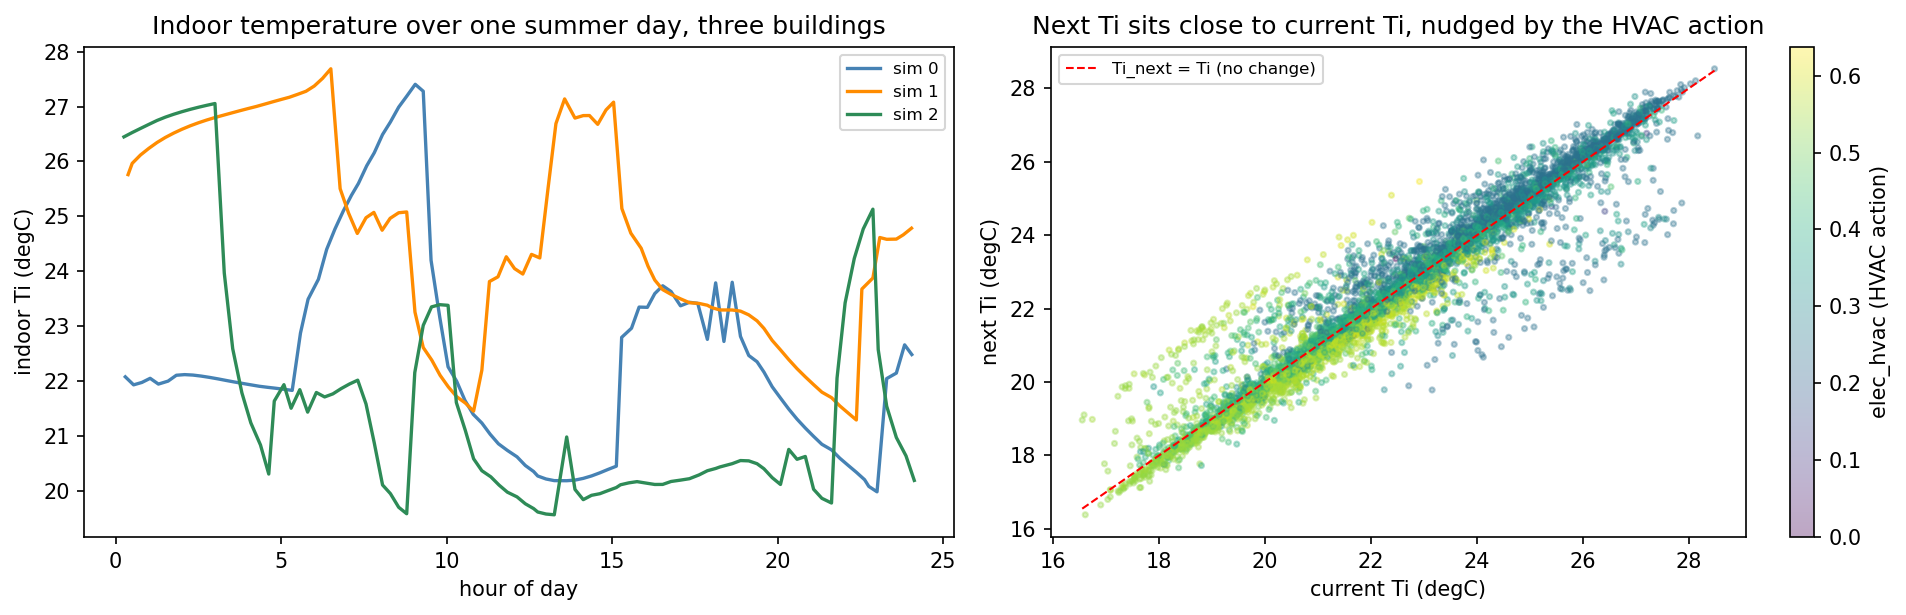

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), dpi=150)

# (a) one summer day's indoor-temperature trajectory for three different buildings
for sid, color in zip([0, 1, 2], ["steelblue", "darkorange", "seagreen"]):
    day = df[(df.sim_id == sid) & (df.day_of_year == 200)].sort_values("time")
    axes[0].plot(day["time"], day["Ti"], color=color, lw=1.6, label=f"sim {sid}")
axes[0].set_xlabel("hour of day"); axes[0].set_ylabel("indoor Ti (degC)")
axes[0].set_title("Indoor temperature over one summer day, three buildings"); axes[0].legend(fontsize=8)

# (b) next Ti vs current Ti, colored by the HVAC action. Points hug the diagonal
# (strong persistence); the control input nudges the temperature off it.
sample = df.sample(6000, random_state=0)
sc = axes[1].scatter(sample["Ti"], sample["Ti_next"], s=6, alpha=0.35,
                     c=sample["elec_hvac"], cmap="viridis")
lims = [sample["Ti"].min(), sample["Ti"].max()]
axes[1].plot(lims, lims, "r--", lw=1.0, label="Ti_next = Ti (no change)")
axes[1].set_xlabel("current Ti (degC)"); axes[1].set_ylabel("next Ti (degC)")
axes[1].set_title("Next Ti sits close to current Ti, nudged by the HVAC action")
axes[1].legend(fontsize=8, loc="upper left")
fig.colorbar(sc, ax=axes[1], label="elec_hvac (HVAC action)")
plt.tight_layout(); plt.show()

**Reading the plots:** On the left, each building's indoor temperature follows a smooth daily arc — it drifts and is pulled back, it does not jump. On the right, `Ti_next` sits almost on the diagonal against the current `Ti`: the next temperature is mostly the current one (strong **persistence**), with the HVAC action (color) nudging it up or down. That is the honest picture of the problem — a good baseline is "assume no change," and the model earns its keep by predicting the *small* nudge on top. It is a learnable pattern, which is encouraging for the network we are about to train.

## 3. Train the forward model with hyperparameter tuning and regularization

`simple-mlp.ipynb` already built a regression MLP from scratch — one hidden layer, sigmoid neurons, backpropagation, gradient descent. Here we use scikit-learn's `MLPRegressor`, the same idea (now with a single **linear** output neuron, matched to the squared-error loss for regression) wrapped in a reusable, tunable estimator. We tune the network's **depth** (1–3 hidden layers), each layer's **width** (16–128 neurons), and the L2 regularization strength `alpha` — with **Optuna** driving the search.

Optuna's **TPE (Tree-structured Parzen Estimator)** sampler is a Bayesian optimizer: it builds a model of which hyperparameter regions have scored well and preferentially samples there, so it lands on a strong configuration in far fewer trials than an exhaustive sweep. It also searches `alpha` over a **continuous, log-scaled** range and chooses the number of layers itself, rather than trying a fixed list.

**Two dataset-specific choices worth calling out:**
- Even on this reduced 10-building dataset, training on *every* training row each trial is slower than we need. We tune on a **subsample** of the training rows, then refit the chosen configuration on the *full* training set for the final model.
- Each trial is scored by RMSE on the **validation days** held out in Section 2.2. That is the right yardstick here: a k-fold cross-validation would shuffle rows *within* the training period, so a timestep and its near-identical neighbour would land in different folds and inflate the score. Scoring on later, unseen days measures the future-generalization a controller actually needs. The **test** days stay untouched until the final report.

In [15]:
# subsample the training rows for a fast search
n_sub = min(20_000, len(X_train))
sub_idx = rng.choice(len(X_train), n_sub, replace=False)
X_sub, y_sub = X_train.iloc[sub_idx], y_train.to_numpy()[sub_idx]
print(f"search subsample: {n_sub:,} rows")

# Tune MLPRegressor with Optuna (TPE Bayesian search). Optuna chooses the network DEPTH
# (1-3 hidden layers), each layer's WIDTH (16-128 neurons), and the L2 strength alpha
# over a continuous log-scaled range -- proposing each trial from a model of what has
# scored well, instead of scanning a fixed set of combinations. Each trial trains once on
# the training subsample and is scored on the held-out VALIDATION days. The scaler lives
# inside the pipeline, so it is fitted on the training rows only.
def make_pipeline(hidden_layer_sizes, alpha):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("mlp", MLPRegressor(hidden_layer_sizes=hidden_layer_sizes, alpha=alpha,
                             solver="adam", max_iter=150, early_stopping=True,
                             validation_fraction=0.15, n_iter_no_change=8, random_state=0)),
    ])

def suggest_architecture(trial):
    n_layers = trial.suggest_int("n_layers", 1, 3)
    return tuple(trial.suggest_categorical(f"n_units_l{i}", [16, 32, 64, 128])
                 for i in range(n_layers))

def objective(trial):
    hidden = suggest_architecture(trial)
    alpha = trial.suggest_float("alpha", 1e-5, 1e-1, log=True)
    pipe = make_pipeline(hidden, alpha).fit(X_sub, y_sub)
    return mean_squared_error(y_val, pipe.predict(X_val)) ** 0.5

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=0))
study.optimize(objective, n_trials=20, show_progress_bar=True)

bp = study.best_params
best_hidden = tuple(bp[f"n_units_l{i}"] for i in range(bp["n_layers"]))
best_alpha = bp["alpha"]
print("best architecture:", best_hidden, "| alpha:", best_alpha)
print(f"best validation RMSE: {study.best_value:.4f} degC")

search subsample: 20,000 rows


  0%|          | 0/20 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


best architecture: (32, 128) | alpha: 0.0033410807053064692
best validation RMSE: 0.2499 degC


/opt/anaconda3/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (150) reached and the optimization hasn't converged yet.
  warnings.warn(


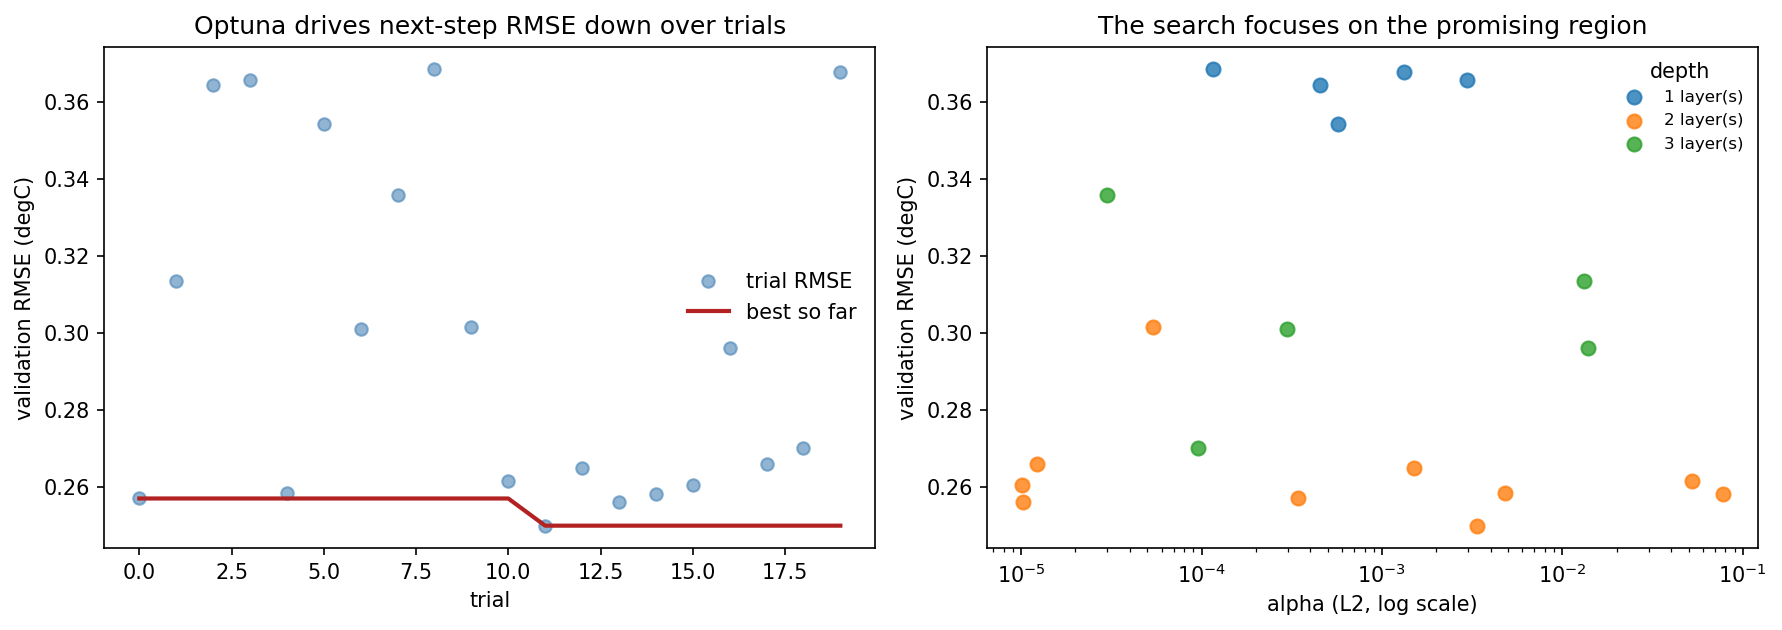

best trial: 11 -> architecture (32, 128) alpha 0.00334


In [16]:
trials = study.trials_dataframe()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3), dpi=150)
axes[0].plot(trials["number"], trials["value"], "o", color="steelblue", alpha=0.6, label="trial RMSE")
axes[0].plot(trials["number"], trials["value"].cummin(), color="firebrick", lw=2, label="best so far")
axes[0].set_xlabel("trial"); axes[0].set_ylabel("validation RMSE (degC)")
axes[0].set_title("Optuna drives next-step RMSE down over trials")
axes[0].legend(frameon=False)

for nl in sorted(trials["params_n_layers"].dropna().unique()):
    m = trials["params_n_layers"] == nl
    axes[1].scatter(trials.loc[m, "params_alpha"], trials.loc[m, "value"],
                    s=45, alpha=0.8, label=f"{int(nl)} layer(s)")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha (L2, log scale)"); axes[1].set_ylabel("validation RMSE (degC)")
axes[1].set_title("The search focuses on the promising region")
axes[1].legend(frameon=False, title="depth", fontsize=8)
plt.tight_layout(); plt.show()

print("best trial:", study.best_trial.number, "-> architecture", best_hidden, "alpha", round(best_alpha, 5))

**Reading the search:** the left panel is the optimization history — each dot is one trial's validation RMSE (in °C), and the running-best curve steps down as Optuna homes in on good configurations. The right panel shows *where* it sampled: `alpha` (log scale) against RMSE, colored by network depth. Early trials scatter across the range; later ones cluster in the low-RMSE region the sampler has learned to trust. The usual tension still governs the outcome — too-small `alpha` lets the network fit noise in the subsample, too-large `alpha` pulls every weight toward zero and underfits — and the chosen point sits in the middle ground, backed by validation days the network never trained on.

In [17]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(hidden_layer_sizes=best_hidden, alpha=best_alpha,
        solver="adam", max_iter=150, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=8, random_state=0)),
])
final_model.fit(X_train, y_train)

val_pred = final_model.predict(X_val)
test_pred = final_model.predict(X_test)

# Baselines. The one that matters for next-step prediction is PERSISTENCE: assume the
# temperature does not change (Ti_next = Ti). A useful model must beat it.
persistence_pred = X_test["Ti"].to_numpy()
mean_pred = DummyRegressor(strategy="mean").fit(X_train, y_train).predict(X_test)
linear_pred = LinearRegression().fit(X_train, y_train).predict(X_test)

print(f"{'model':<20}{'MAE (degC)':>12}{'RMSE (degC)':>13}{'R2':>9}")
for name, pred in [("mean baseline", mean_pred), ("persistence", persistence_pred),
                   ("linear regression", linear_pred), ("forward ANN", test_pred)]:
    print(f"{name:<20}{mean_absolute_error(y_test, pred):>12.4f}"
          f"{mean_squared_error(y_test, pred)**0.5:>13.4f}{r2_score(y_test, pred):>9.4f}")

pers_rmse = mean_squared_error(y_test, persistence_pred) ** 0.5
ann_rmse = mean_squared_error(y_test, test_pred) ** 0.5
print(f"\nforward ANN cuts next-step RMSE by {100*(1-ann_rmse/pers_rmse):.1f}% vs persistence "
      f"({pers_rmse:.4f} -> {ann_rmse:.4f} degC)")
print(f"validation RMSE: {mean_squared_error(y_val, val_pred)**0.5:.4f} degC")

model                 MAE (degC)  RMSE (degC)       R2
mean baseline             2.0019       2.3909  -0.0033
persistence               0.4069       0.6836   0.9180
linear regression         0.2992       0.3988   0.9721
forward ANN               0.1667       0.2390   0.9900

forward ANN cuts next-step RMSE by 65.0% vs persistence (0.6836 -> 0.2390 degC)
validation RMSE: 0.2371 degC


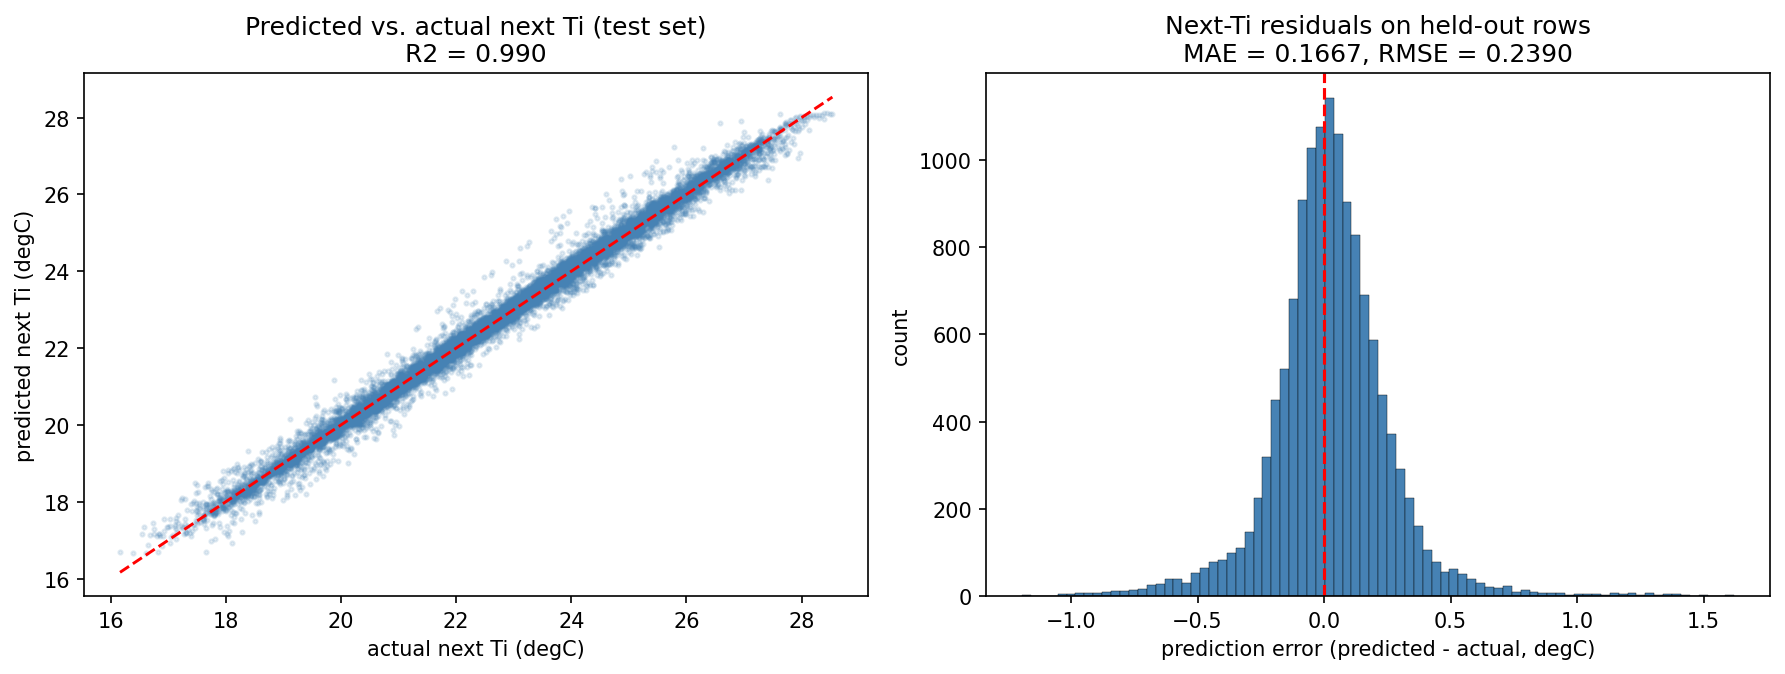

In [18]:
mae = mean_absolute_error(y_test, test_pred)
rmse = mean_squared_error(y_test, test_pred) ** 0.5
r2 = r2_score(y_test, test_pred)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), dpi=150)
axes[0].scatter(y_test, test_pred, s=4, alpha=0.15, color="steelblue")
lims = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
axes[0].plot(lims, lims, "r--", lw=1.4)
axes[0].set_xlabel("actual next Ti (degC)"); axes[0].set_ylabel("predicted next Ti (degC)")
axes[0].set_title(f"Predicted vs. actual next Ti (test set)\nR2 = {r2:.3f}")

resid = test_pred - y_test.to_numpy()
axes[1].hist(resid, bins=80, color="steelblue", edgecolor="black", linewidth=0.2)
axes[1].axvline(0, color="red", ls="--")
axes[1].set_xlabel("prediction error (predicted - actual, degC)"); axes[1].set_ylabel("count")
axes[1].set_title(f"Next-Ti residuals on held-out rows\nMAE = {mae:.4f}, RMSE = {rmse:.4f}")
plt.tight_layout(); plt.show()

**Takeaway:** The forward ANN beats both the mean baseline and — the one that matters — **persistence**, the assumption that the temperature does not change. Beating persistence means the model has genuinely learned how the state, weather, and control action move the temperature, not just that "next ≈ now." That accuracy on the *change* is what makes look-ahead control possible: a controller can trust the model's answer to *"if I apply this action, where does Ti go?"* several steps out. The residual histogram is centred near zero, so the model is not systematically biased — it predicts the next temperature about equally well whether it is rising or falling.

## 4. Using the forward model for control

Now the payoff. The model predicts *one* timestep. A controller needs to look further: *"if I hold the thermostat here, where is the building in an hour? in a day?"* You get that by **rolling the model forward** — predict the next `Ti`, feed that prediction back in as the current `Ti`, and repeat. Each step is a millisecond, so a whole day of look-ahead costs less than a single physics-simulation timestep would. This is the core computation inside **model-predictive control (MPC)**.

<img src="https://raw.githubusercontent.com/IIB-Lab/AI-ML-bootcamp-tutorials/main/04-deep-learning/mlp/images/03_hvac-energy-surrogate-ann-fig3.png" alt="03_hvac-energy-surrogate-ann figure 3" width="820">

To make this concrete, the next cell replays one real test day for one building, three times, holding the **setpoint** — the model's control input — at 22, 24, and 26 °C. Everything the controller cannot choose (weather, solar, wind, time of day) comes from the recorded day. Everything it *can* choose is fixed by us. The question the plot answers is the one a controller asks: **given this thermostat schedule, where does the indoor temperature actually go?**

Two honest caveats. The rollout compounds its own error — every step's small mistake becomes part of the next step's input — so a trajectory drifts further from truth the longer it runs. And `mrt` and `rh` are held at their recorded values rather than co-evolving with `Ti`, which a full plant model would do.

setpoint 22 degC -> Ti starts at 24.00, after 1 h 21.66, final-hour mean 20.97 degC
setpoint 24 degC -> Ti starts at 24.00, after 1 h 23.85, final-hour mean 23.59 degC
setpoint 26 degC -> Ti starts at 24.00, after 1 h 24.09, final-hour mean 25.74 degC


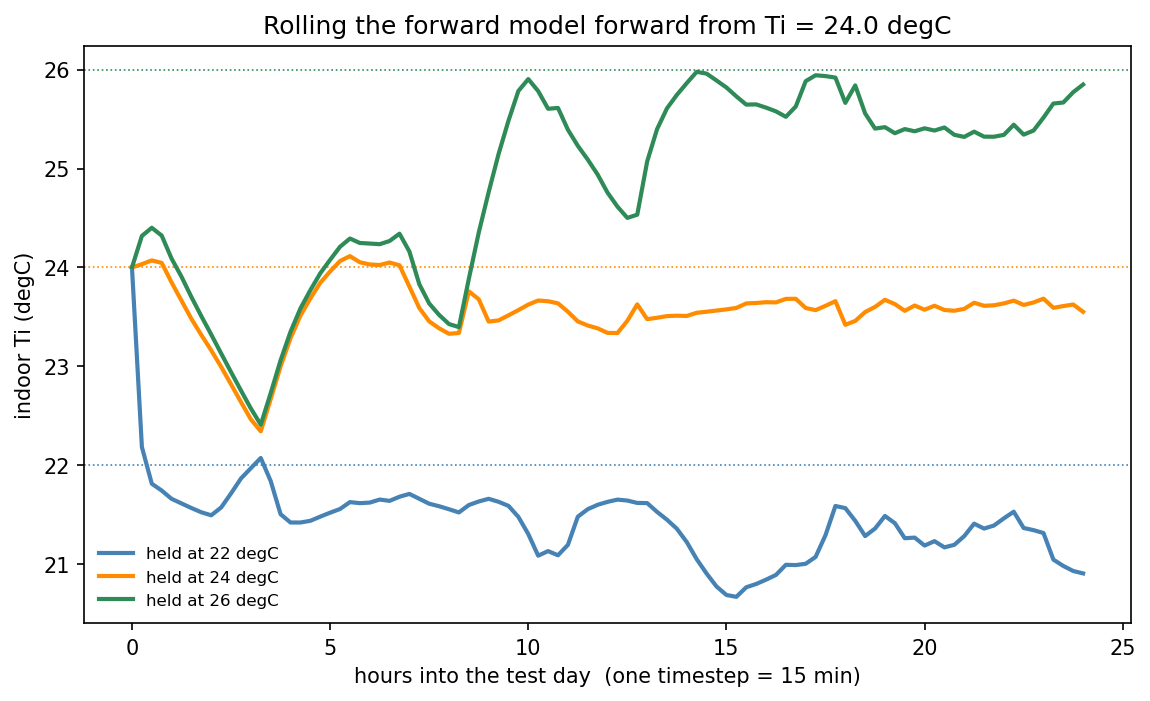

In [23]:
# Closing the loop. Take one test day of one building and roll the forward model forward
# through it, once per setpoint. At each timestep the model predicts the next Ti, and that
# prediction becomes the next step's current Ti -- the model, not a simulator, carries the
# state. Weather, solar, wind and time come from the recorded day; the setpoint is ours to set.
HORIZON = 96                     # 96 timesteps x 15 min = one full day
setpoints = [22.0, 24.0, 26.0]

# Starting indoor temperature. None means "begin from the day's recorded Ti". Set a number
# to start the building anywhere you like -- try a cold 17.0 or a hot 27.0. Keep it inside
# the training range (Ti spans ~16-29 degC there); outside it the model is extrapolating.
START_TI = 24

sim = (df[is_test & (df["sim_id"] == 0)]
       .sort_values(["day_of_year", "time"]).head(HORIZON).reset_index(drop=True))

def rollout(setpoint):
    """Roll the forward model through one day, holding the thermostat at `setpoint`."""
    Ti = sim.loc[0, "Ti"] if START_TI is None else START_TI
    trajectory = [Ti]
    for t in range(HORIZON):
        step = sim.loc[[t], feature_cols].copy()
        step["Ti"] = Ti                         # feed the prediction back in
        step["setpoint"] = setpoint             # the control input we are holding fixed
        Ti = final_model.predict(step)[0]
        trajectory.append(Ti)
    return np.array(trajectory)
# (mrt and rh stay at their recorded values -- a full plant model would evolve them too,
#  so the rollout is a simplified but honest picture of the closed loop.)

hours = np.arange(HORIZON + 1) * 0.25
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)
# ax.plot(hours[:-1], sim["Ti"], color="gray", lw=1.3, alpha=0.8, label="recorded Ti (what the building did)")
for setpoint, color in zip(setpoints, ["steelblue", "darkorange", "seagreen"]):
    trajectory = rollout(setpoint)
    ax.plot(hours, trajectory, color=color, lw=2, label=f"held at {setpoint:.0f} degC")
    ax.axhline(setpoint, color=color, lw=0.8, ls=":")
    print(f"setpoint {setpoint:.0f} degC -> Ti starts at {trajectory[0]:.2f}, "
          f"after 1 h {trajectory[4]:.2f}, final-hour mean {trajectory[-4:].mean():.2f} degC")
ax.set_xlabel("hours into the test day  (one timestep = 15 min)")
ax.set_ylabel("indoor Ti (degC)")
ax.set_title(f"Rolling the forward model forward from Ti = "
             f"{sim.loc[0, 'Ti'] if START_TI is None else START_TI:.1f} degC")
ax.legend(fontsize=8, frameon=False)
plt.show()

**Reading the plot:** time runs left to right across one test day. Each line is the model's own rolled-out trajectory when we hold the setpoint fixed at a different value (dotted line, matching color).

All three rollouts start from the same temperature, **separate within the first hour, and then hold their own band for the rest of the day, ordered exactly as the setpoints are.** The model has learned that the thermostat target pulls the indoor air toward it, and roughly how fast: the rise is smooth over an hour or two, not instant, because the building has thermal mass. Each band settles about half a degree *below* its target and still ripples with the afternoon sun — a real thermostat does not sit perfectly on its setpoint either, and the model has reproduced the offset and the weather sensitivity rather than a flat line.

**Try changing `START_TI`.** Start the building cold at 17 °C or hot at 27 °C and re-run: the trajectories look different for the first hour, then land on exactly the same bands. The initial temperature is *forgotten* within about four timesteps. That is a real property of the building, not a quirk of the model — thermal mass and the thermostat wash out where you started, and what governs the rest of the day is the setpoint plus the weather. It is also why a controller can afford to re-plan from wherever the building happens to be.

That separation is what makes look-ahead control possible. A controller can ask the model *"where does each candidate schedule put me over the next several hours?"* and pick the one that stays near the setpoint at the least energy — thousands of times, in the time a physics simulator would take to start. Note also what the plot does **not** promise: because each step's error feeds the next, a day-long trajectory is a plausible path, not a guaranteed one. Real MPC re-plans at every timestep from the *measured* temperature, which never lets the compounding error get far.

## Summary

- A controller that plans ahead needs a **fast one-step forward model** of the building's dynamics — predict the next state given the current state and a candidate control input — because a physics simulation is far too slow to query inside the control loop.
- The target is `Ti_next`, the next timestep's indoor temperature. The predictors are the current indoor state (`Ti`, `mrt`, `rh`), weather, solar, wind, time, **and `setpoint` — the control input the model must see to predict the result.** The `elec_*` meters were dropped: they are *outcomes* of the thermostat's decisions, not inputs a controller gets to choose.
- The target is built **leak-safe** with a grouped shift: `Ti_next` is `Ti` shifted one step *within each `sim_id`*, so a row's next temperature never comes from another building.
- Because a forward model must work on days it has never seen, we split **by time period** — train on the early season, validate and test on later, unseen days — a stricter, more honest test than a random shuffle. The baseline that matters is **persistence** (assume no temperature change); the forward ANN, tuned over depth, width, and L2 `alpha` with **Optuna** scored on the held-out validation days, beat persistence, the mean baseline, and linear regression on the test rows.
- The forward model's real use is **control**: roll it forward by feeding each prediction back in as the next step's state, and read off where a given setpoint drives the temperature — the inner loop of model-predictive control (MPC). Errors compound across a long rollout, which is why real MPC re-plans from the measured temperature every step.

## References

- Course notebook: `04-deep-learning/mlp/simple-mlp.ipynb`.
- Course notebook: `04-deep-learning/mlp/wafer-defect-detection-ann.ipynb` (the classification counterpart to this regression notebook).
- scikit-learn documentation: `MLPRegressor`, `StandardScaler`, `Pipeline`.
- Optuna documentation: the `TPESampler` Bayesian search used for hyperparameter tuning.
- Model-predictive control (MPC) for buildings — the real-world basis of Section 4, where a fast learned forward model is queried in the control loop to choose HVAC actions.